In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Basic Dataset Statistics

In [13]:
df = pd.read_csv("../data/sententence_data.csv")

In [14]:
# Display first few rows
print("First few rows of the dataset:")
df.head()

First few rows of the dataset:


,pair_ID,sentence_A,sentence_B,entailment_AB,entailment_BA
0,1,A group of kids is playing in a yard and an ol...,A group of boys in a yard is playing and a man...,A_neutral_B,B_neutral_A
1,2,A group of children is playing in the house an...,A group of kids is playing in a yard and an ol...,A_contradicts_B,B_neutral_A
2,3,The young boys are playing outdoors and the ma...,The kids are playing outdoors near a man with ...,A_entails_B,B_entails_A
3,4,The young boys are playing outdoors and the ma...,There is no boy playing outdoors and there is ...,A_contradicts_B,B_contradicts_A
4,5,The kids are playing outdoors near a man with ...,A group of kids is playing in a yard and an ol...,A_neutral_B,B_neutral_A


### Checking for missing Values

In [6]:
# Check for missing values
print("\nMissing values in each column:")
df.isnull().sum()


Missing values in each column:


pair_ID          0
sentence_A       0
sentence_B       0
entailment_AB    0
entailment_BA    0
dtype: int64

### Distribution of entailment classes AB

In [7]:
print("\nDistribution of entailment_AB classes:")
ab_counts = df['entailment_AB'].value_counts()
print(ab_counts)
df['entailment_AB'].value_counts(normalize=True).round(3)


Distribution of entailment_AB classes:
entailment_AB
A_neutral_B        5268
A_entails_B        2821
A_contradicts_B    1751
Name: count, dtype: int64


entailment_AB
A_neutral_B        0.535
A_entails_B        0.287
A_contradicts_B    0.178
Name: proportion, dtype: float64

### Distribution of entailment classes BA

In [8]:
print("\nDistribution of entailment_BA classes:")
ba_counts = df['entailment_BA'].value_counts()
print(ba_counts)
df['entailment_BA'].value_counts(normalize=True).round(3)


Distribution of entailment_BA classes:
entailment_BA
B_neutral_A        6832
B_contradicts_A    1708
B_entails_A        1300
Name: count, dtype: int64


entailment_BA
B_neutral_A        0.694
B_contradicts_A    0.174
B_entails_A        0.132
Name: proportion, dtype: float64

### Visualize distribution of entailment classes

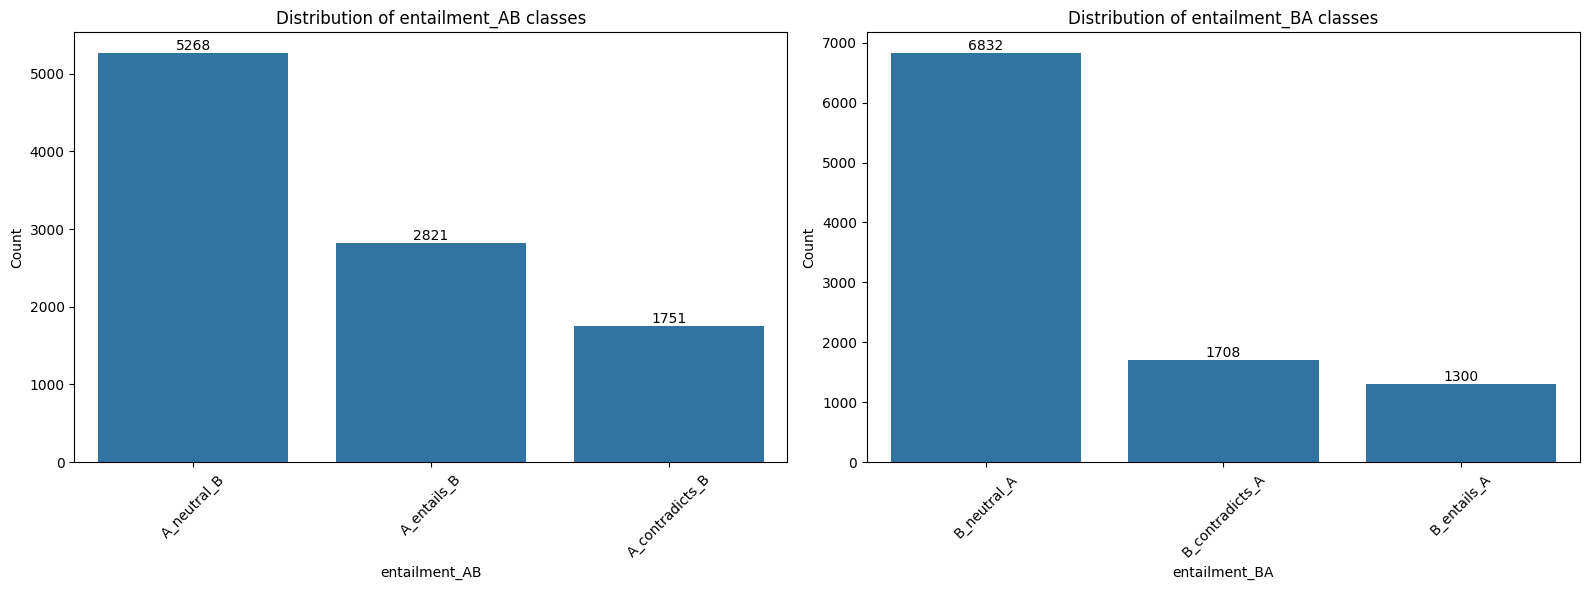

In [9]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
ax=sns.barplot(x=ab_counts.index, y=ab_counts.values)
plt.title('Distribution of entailment_AB classes')
plt.xticks(rotation=45)
plt.ylabel('Count')
ax.bar_label(ax.containers[0])

plt.subplot(1, 2, 2)
ax=sns.barplot(x=ba_counts.index, y=ba_counts.values)
plt.title('Distribution of entailment_BA classes')
plt.xticks(rotation=45)
plt.ylabel('Count')
ax.bar_label(ax.containers[0])

plt.tight_layout()
plt.show()

### Distribution of seven-category classification

In [10]:
df['seven_category'] = df.apply(lambda row:
                                f"{row['entailment_AB']}_{row['entailment_BA']}", axis=1)

print("\nDistribution of seven-category classification:")
seven_counts = df['seven_category'].value_counts()
print(seven_counts)
df['seven_category'].value_counts(normalize=True).round(3)


Distribution of seven-category classification:
seven_category
A_neutral_B_B_neutral_A            4992
A_entails_B_B_neutral_A            1513
A_contradicts_B_B_contradicts_A    1424
A_entails_B_B_entails_A            1300
A_contradicts_B_B_neutral_A         327
A_neutral_B_B_contradicts_A         276
A_entails_B_B_contradicts_A           8
Name: count, dtype: int64


seven_category
A_neutral_B_B_neutral_A            0.507
A_entails_B_B_neutral_A            0.154
A_contradicts_B_B_contradicts_A    0.145
A_entails_B_B_entails_A            0.132
A_contradicts_B_B_neutral_A        0.033
A_neutral_B_B_contradicts_A        0.028
A_entails_B_B_contradicts_A        0.001
Name: proportion, dtype: float64

### Visualize seven-category distribution

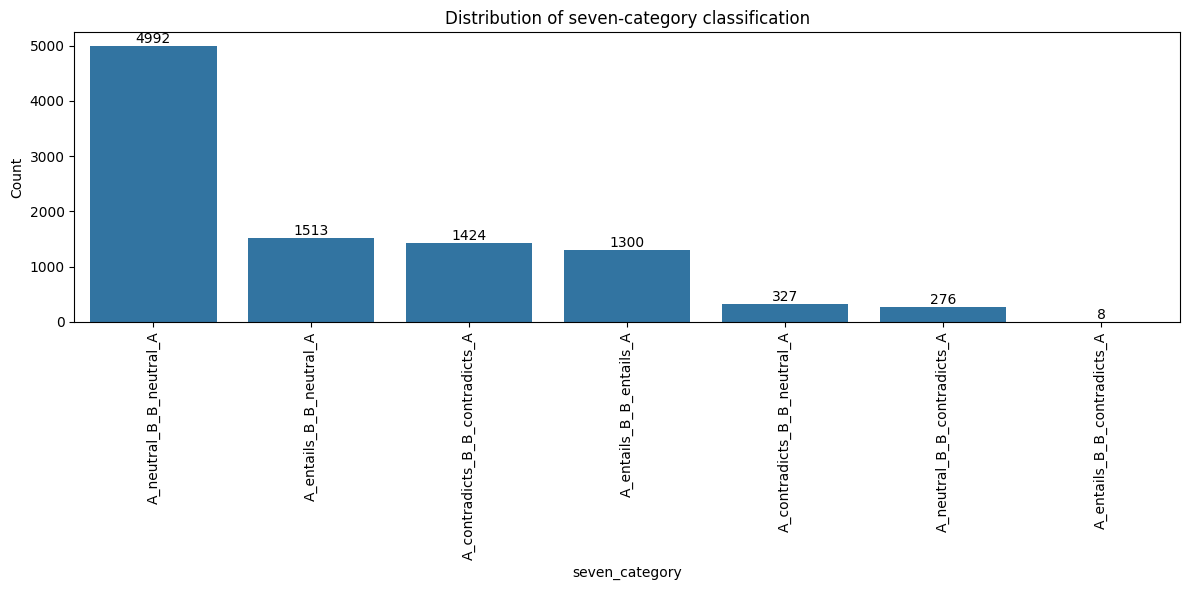

In [11]:
plt.figure(figsize=(12, 6))
ax= sns.barplot(x=seven_counts.index, y=seven_counts.values)
plt.title('Distribution of seven-category classification')
plt.xticks(rotation=90)
plt.ylabel('Count')
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()